In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [22]:
# Fetch NVIDIA high-frequency minute data
ticker = "NVDA"
data = yf.download(ticker, period="1d", interval="1m")
data

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2024-12-06 09:30:00-05:00,144.630005,144.880005,144.270004,144.300095,144.300095,13290439
2024-12-06 09:31:00-05:00,144.285004,144.690002,144.175003,144.339996,144.339996,862446
2024-12-06 09:32:00-05:00,144.339996,145.389999,144.259995,145.310104,145.310104,1445256
2024-12-06 09:33:00-05:00,145.312698,145.449997,144.960007,145.309998,145.309998,904674
2024-12-06 09:34:00-05:00,145.300003,145.649994,145.210007,145.531693,145.531693,924313
...,...,...,...,...,...,...
2024-12-06 15:55:00-05:00,142.125000,142.399994,142.125000,142.350006,142.350006,1040124
2024-12-06 15:56:00-05:00,142.359207,142.369995,142.240005,142.345001,142.345001,495506
2024-12-06 15:57:00-05:00,142.350006,142.380005,142.270004,142.360504,142.360504,594087


In [23]:
# Prepare the data
data.reset_index(inplace=True)
data["Datetime"] = pd.to_datetime(data["Datetime"])
data.set_index("Datetime", inplace=True)
minute_close_prices = data["Close"]
minute_volume = data["Volume"]

In [24]:
# Simulate some trades
np.random.seed(42)
trade_signals = pd.DataFrame({
    "timestamp": minute_close_prices.index[::10],  # Every 10th minute
    "trade_size": np.random.choice([-100, 100, 200, -200], size=len(minute_close_prices[::10]))
})
trade_signals

,timestamp,trade_size
0,2024-12-06 09:30:00-05:00,200
1,2024-12-06 09:40:00-05:00,-200
2,2024-12-06 09:50:00-05:00,-100
3,2024-12-06 10:00:00-05:00,200
4,2024-12-06 10:10:00-05:00,200
5,2024-12-06 10:20:00-05:00,-200
6,2024-12-06 10:30:00-05:00,-100
7,2024-12-06 10:40:00-05:00,-100
8,2024-12-06 10:50:00-05:00,200
9,2024-12-06 11:00:00-05:00,100


In [25]:
# Define a market impact model
def market_impact(order_size, adv, gamma=0.4, eta=0.001, decay_factor=0.05, liquidity_factor=0.1):
    """
    A complex market impact model with non-linear impacts, time decay, and liquidity adjustment.
    """
    # Permanent impact scales quadratically with trade size
    permanent_impact = gamma * (abs(order_size) / adv) ** 2

    # Temporary impact with a time decay factor
    temporary_impact = eta * np.sign(order_size) * (1 - np.exp(-decay_factor * abs(order_size)))

    # Liquidity adjustment based on order size and ADV
    liquidity_adjustment = liquidity_factor * (abs(order_size) / adv)

    return permanent_impact, temporary_impact, liquidity_adjustment


In [26]:
# Simulate market impact
def simulate_market_impact(price_data, trade_signals, volume_data, impact_model):
    # Calculate Average Daily Volume (ADV)
    adv = volume_data.resample('D').sum().mean()
    impacted_prices = price_data.copy()
    transaction_cost = 0

    for _, trade in trade_signals.iterrows():
        timestamp = trade["timestamp"]
        order_size = trade["trade_size"]
        
        if timestamp not in impacted_prices.index:
            continue
        
        permanent_impact, temporary_impact, liquidity_adjustment = impact_model(order_size, adv)
        
        # Adjust current price (temporary impact with liquidity adjustment)
        impacted_prices.loc[timestamp] *= (1 + temporary_impact + liquidity_adjustment)
        
        # Adjust future prices (permanent impact)
        future_timestamps = impacted_prices.index[impacted_prices.index >= timestamp]
        impacted_prices.loc[future_timestamps] *= (1 + permanent_impact)

        transaction_cost += order_size * (impacted_prices.loc[timestamp]-price_data.loc[timestamp])
    
    return impacted_prices, transaction_cost

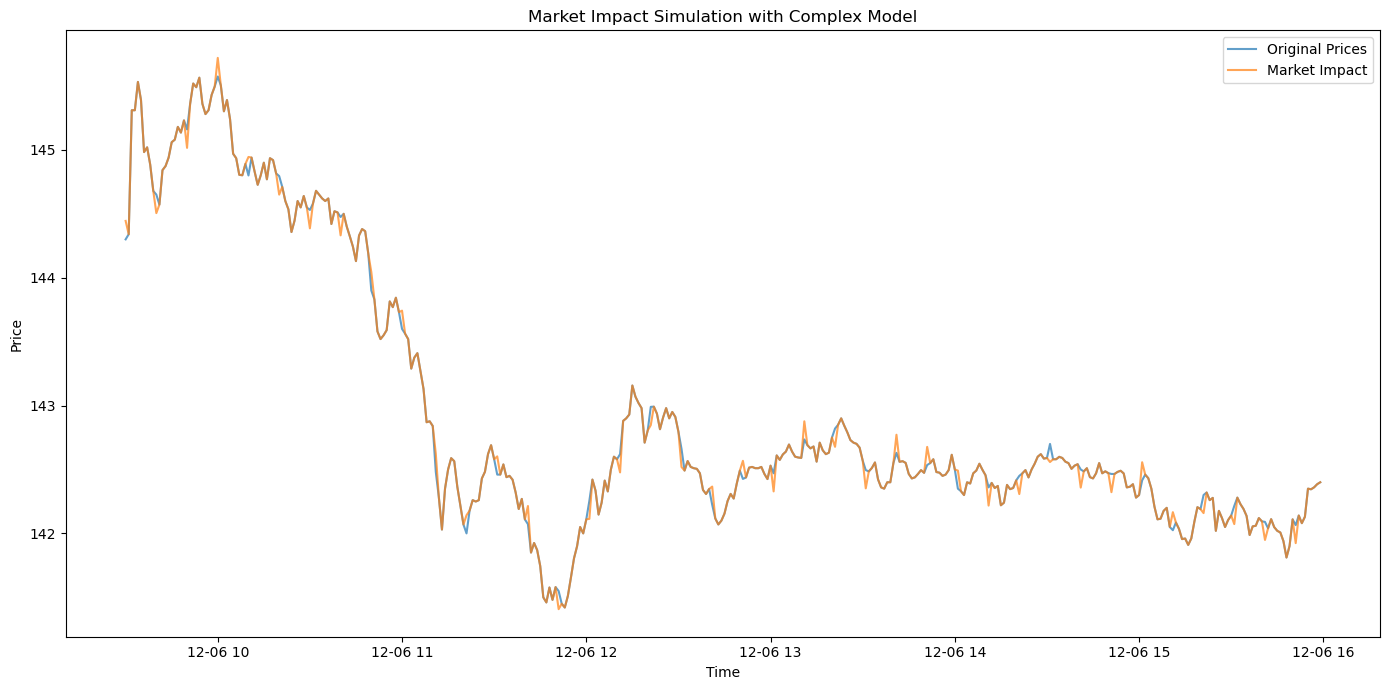

In [27]:
# Visualize results
models = {
    "Market Impact": market_impact
}

fig, ax = plt.subplots(figsize=(14, 7))

for model_name, impact_model in models.items():
    impacted_prices, transaction_cost = simulate_market_impact(data['Close'], trade_signals, data['Volume'], impact_model)
    ax.plot(data['Close'], label="Original Prices", alpha=0.7)
    ax.plot(impacted_prices, label=model_name, alpha=0.7)

ax.set_title("Market Impact Simulation with Complex Model")
ax.set_ylabel("Price")
ax.legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()

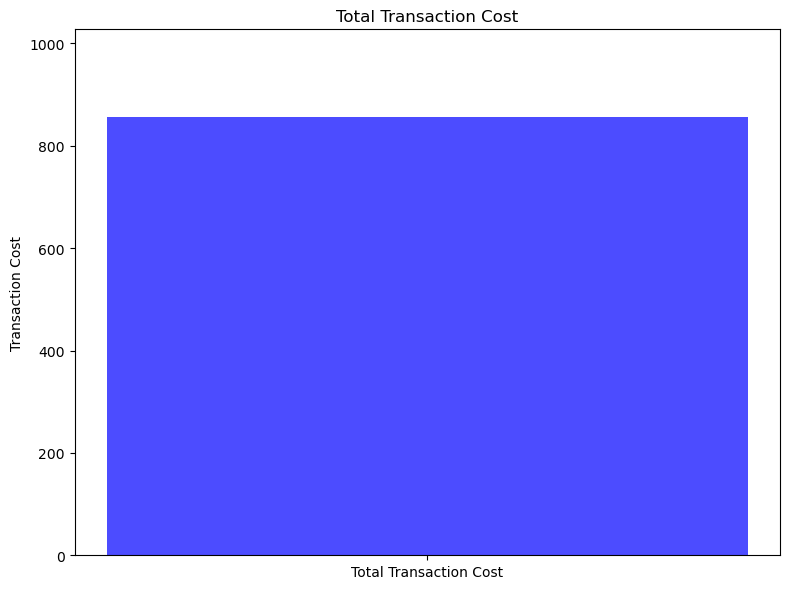

In [ ]:
# Plot a single bar for total transaction cost
plt.figure(figsize=(8, 6))
plt.bar(["Total Transaction Cost"], [transaction_cost], color='blue', alpha=0.7, width=0.2)
plt.title("Total Transaction Cost")
plt.ylabel("Transaction Cost")
plt.tight_layout()
plt.show()

In [29]:
# Simulated observed price impacts for parameter estimation
def simulate_observed_impacts(price_data, trade_signals, adv):
    observed_impacts = []
    for _, trade in trade_signals.iterrows():
        timestamp = trade["timestamp"]
        order_size = trade["trade_size"]

        if timestamp not in price_data.index:
            continue
        
        # Observed price change (next price relative to the current)
        current_price = price_data.loc[timestamp]
        next_timestamp = price_data.index[price_data.index > timestamp].min()
        if next_timestamp is not None:
            next_price = price_data.loc[next_timestamp]
            observed_change = (next_price - current_price) / current_price
            observed_impacts.append((order_size, observed_change))
    return np.array(observed_impacts)

# Function to fit
def fit_market_impact(order_size, gamma, eta, decay_factor, liquidity_factor, adv):
    permanent_impact = gamma * (np.abs(order_size) / adv) ** 2
    temporary_impact = eta * np.sign(order_size) * (1 - np.exp(-decay_factor * np.abs(order_size)))
    liquidity_adjustment = liquidity_factor * (np.abs(order_size) / adv)
    return permanent_impact + temporary_impact + liquidity_adjustment

# Observed impacts (generated from trades)
adv = minute_volume.resample('D').sum().mean()  # Average daily volume
observed_impacts = simulate_observed_impacts(minute_close_prices, trade_signals, adv)

# Extract order sizes and observed price changes
order_sizes = observed_impacts[:, 0]
observed_changes = observed_impacts[:, 1]

# Fit the model to observed data
initial_guess = [0.4, 0.04, 0.05, 0.1]
params, covariance = curve_fit(
    lambda x, gamma, eta, decay_factor, liquidity_factor: fit_market_impact(x, gamma, eta, decay_factor, liquidity_factor, adv),
    order_sizes,
    observed_changes,
    p0=initial_guess
)

# Extract the fitted parameters
gamma_estimated, eta_estimated, decay_factor_estimated, liquidity_factor_estimated = params

print("Estimated Parameters:")
print(f"Gamma: {gamma_estimated}")
print(f"Eta: {eta_estimated}")
print(f"Decay Factor: {decay_factor_estimated}")
print(f"Liquidity Factor: {liquidity_factor_estimated}")

Estimated Parameters:
Gamma: 1.148925908199782
Eta: -0.0001513138538964435
Decay Factor: 1.1362077061735092
Liquidity Factor: -45.13456125587407


/var/folders/gr/8xsy3n0918xf99l916djm85m0000gn/T/ipykernel_975/357858482.py:37: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(
